<a href="https://colab.research.google.com/github/sevaradevoloper/mldanishla/blob/main/onlinefood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Online Food Ordering Dataset ./ Ovqat zakaz beradimi yoqmi?

In [ ]:
!pip install opendatasets

In [ ]:
!pip install legacy-cgi opendatasets --upgrade

In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/srisyra02/online-food-ordering-dataset")

Skipping, found downloaded files in "./online-food-ordering-dataset" (use force=True to force download)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/online-food-ordering-dataset/online food delivery dataset.csv")

In [ ]:
df.shape

(388, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

📌 Datasetimizdagi 14 ta ustun va ularning ma'nosi:


Age (Yosh): Mijozning yoshi (masalan: 20, 24, 30 yosh).

Gender (Jins): Mijozning jinsi (Male - Erkak, Female - Ayol).

Marital Status (Oilaviy ahvoli): Single (Bo‘ydoq/Turmush qurmagan), Married (Oilali), Prefer not to say (Aytishni xohlamaydi).

Occupation (Kasbi/Bandligi): Student (Talaba), Employee (Xodim), Self Employeed (O‘zi uchun ishlaydi/Tadbirkor), House wife (Uy bekasi).

Monthly Income (Oylik daromadi): Mijozning daromad darajasi (No Income - Daromadsiz, Below Rs.10000, 10001 to 25000, 25001 to 50000, More than 50000).

Educational Qualifications (Ma'lumoti): Graduate (Oliy), Post Graduate (Magistr/Magistraturadan keyin), Ph.D (Doktorant), School (Maktab), Uneducated (Ma'lumotsiz).

Family size (Oila a'zolari soni): Bir oilada nechta kishi yashashi (masalan: 1, 2, 3, 4, 5 kishi).

Customer Type (Mijoz turi): Regular (Doimiy mijoz), Frequent (Tez-tez zakaz qiladigan), New (Yangi mijoz).

latitude va longitude: Mijoz joylashgan joyning geografik xaritadagi koordinatalari (kenglik va uzunlik).

Pin code: Mijoz yashaydigan hududning pochta indeksi.

Feedback (Fikr/Ratsional baho): Mijozning xizmat haqida bildirgan fikri (Positive - Ijobiy, Negative - Salbiy).







Unnamed: 13: Birlamchi CSV fayl
saqlanganda xato tushib qolgan takroriy ustun

🎯 Output (JAVOB - Target ustun): Output. Mijoz keyingi safar ovqat zakaz qiladimi yoki yo‘qmi (Yes - Zakaz qiladi, No - Zakaz qilmaydi). Biz aynan shuni bashorat qiluvchi model quramiz!







Endi bu yerdan kerakmas ustunlarni olib tashlaymiz:


latitude va longitude: Mijoz joylashgan joyning geografik xaritadagi koordinatalari (kenglik va uzunlik).

Pin code: Mijoz yashaydigan hududning pochta indeksi.

Unnamed: 13: Birlamchi CSV fayl saqlanganda xato tushib qolgan takroriy ustun

#Next step: EDA(Explatory Data Analysis) ma'lumotlarni tahlil qilish.

Model qurishdan oldin datasetdan javob topishingiz kerak bo‘lgan asosiy 5 ta tahlil savoli:



Zakaz qilganlar: 217
Zakaz qilmaganlar: 68
Soni bo'yicha:
Output
Yes    301
No      87
Name: count, dtype: int64

Foiz hisobida:
Output
Yes    77.57732
No     22.42268
Name: proportion, dtype: float64


/tmp/ipykernel_1219/2173562939.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Output", palette="Blues_r")


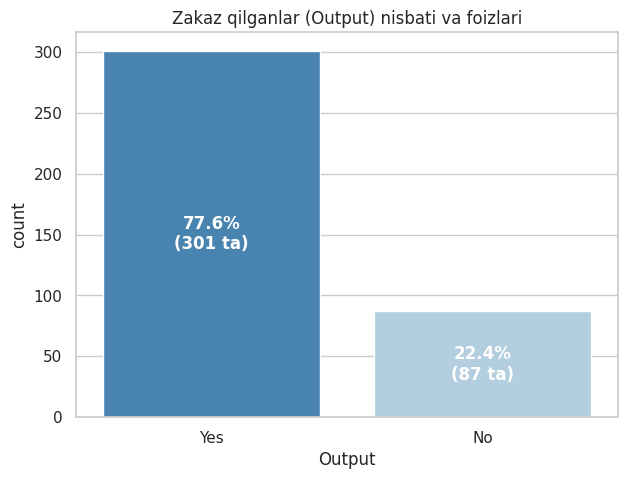

In [ ]:
# Target balansi (Output): Datasetda zakaz qiladiganlar (Yes) va qilmaydiganlar (No) nisbati qanday? (Qaysi biri ko‘proq?)

zakaz_qilganlar= df[df["Output"] == "Yes"].value_counts()
zakaz_qilmaganlar = df[df["Output"] == "No"].value_counts()
print(f"Zakaz qilganlar: {len(zakaz_qilganlar)}")
print(f"Zakaz qilmaganlar: {len(zakaz_qilmaganlar)}")

# Grafik
# 1. Sanab olish va foizni hisoblash
counts = df['Output'].value_counts()
print("Soni bo'yicha:")
print(counts)

print("\nFoiz hisobida:")
print(df['Output'].value_counts(normalize=True) * 100)

# 2. Grafik va Ustunlar ichiga foiz yozish
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="Output", palette="Blues_r")
plt.title('Zakaz qilganlar (Output) nisbati va foizlari')

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{(height / total) * 100:.1f}%\n({int(height)} ta)'
    # Foiz matnini ustunning qoq o'rtasiga joylashtiramiz
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center',
                fontsize=12, color='white', fontweight='bold')

plt.show()

Target balansi (Output):

Datasetda zakaz qiladiganlar (Yes) va qilmaydiganlar (No) nisbati qanday? (Qaysi biri ko‘proq?)

Xulosa:  Zakaz qilganlar  77.6%,va nisbatan ko'p.


count    388.000000
mean      24.628866
std        2.975593
min       18.000000
25%       23.000000
50%       24.000000
75%       26.000000
max       33.000000
Name: Age, dtype: float64
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

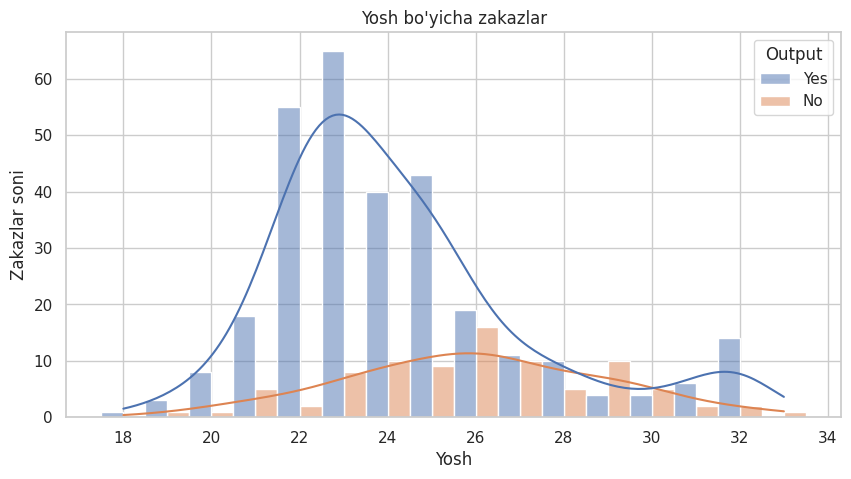

In [ ]:
# Yosh va Zakaz o‘rtasidagi bog‘liqlik: Qaysi yoshdagilar ko‘proq ovqat zakaz qiladi? (Yoshlarmi yoki kattalar?)
print(df["Age"].describe())
# eng kichik yoshlar 18 va eng kattasi 33 yoshlar oraligida ekan
print("- - - "*200)
print("- - - "*200)
# endi ularni ajratamiz:
# Yosh bo'yicha Output (zakaz) soni

yosh_output = df.groupby("Age")["Output"].value_counts()
print(yosh_output)

# Grafik
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Age", hue="Output", kde=True, discrete=True, multiple="dodge")
plt.xlabel('Yosh')
plt.ylabel('Zakazlar soni')
plt.title('Yosh bo\'yicha zakazlar')  # sns.title emas, plt.title ishlatiladi
plt.show()

Yosh va Zakaz o‘rtasidagi bog‘liqlik:

Qaysi yoshdagilar ko‘proq ovqat zakaz qiladi? (Yoshlarmi yoki kattalar?)


Xulosa:

zakaz qilish boyicha koproq yoshlar (21 - 25 yosh oraliqda)

zakaz qilmaslik boyicha koproq yoshlar (23 - 30 yosh oraliqda)

Occupation      Monthly Income   Output
Student         No Income        Yes       157
Employee        25001 to 50000   Yes        33
                More than 50000  Yes        24
Student         No Income        No         21
Employee        25001 to 50000   No         19
Self Employeed  More than 50000  Yes        18
Employee        10001 to 25000   Yes        17
Student         Below Rs.10000   Yes        17
Employee        More than 50000  No         11
Self Employeed  10001 to 25000   Yes        10
                25001 to 50000   No          8
                More than 50000  No          7
House wife      No Income        Yes         7
Employee        10001 to 25000   No          6
                Below Rs.10000   No          6
Self Employeed  25001 to 50000   Yes         6
Student         10001 to 25000   Yes         5
Self Employeed  10001 to 25000   No          5
Student         25001 to 50000   Yes         3
Employee        Below Rs.10000   Yes         2
House wife      No I

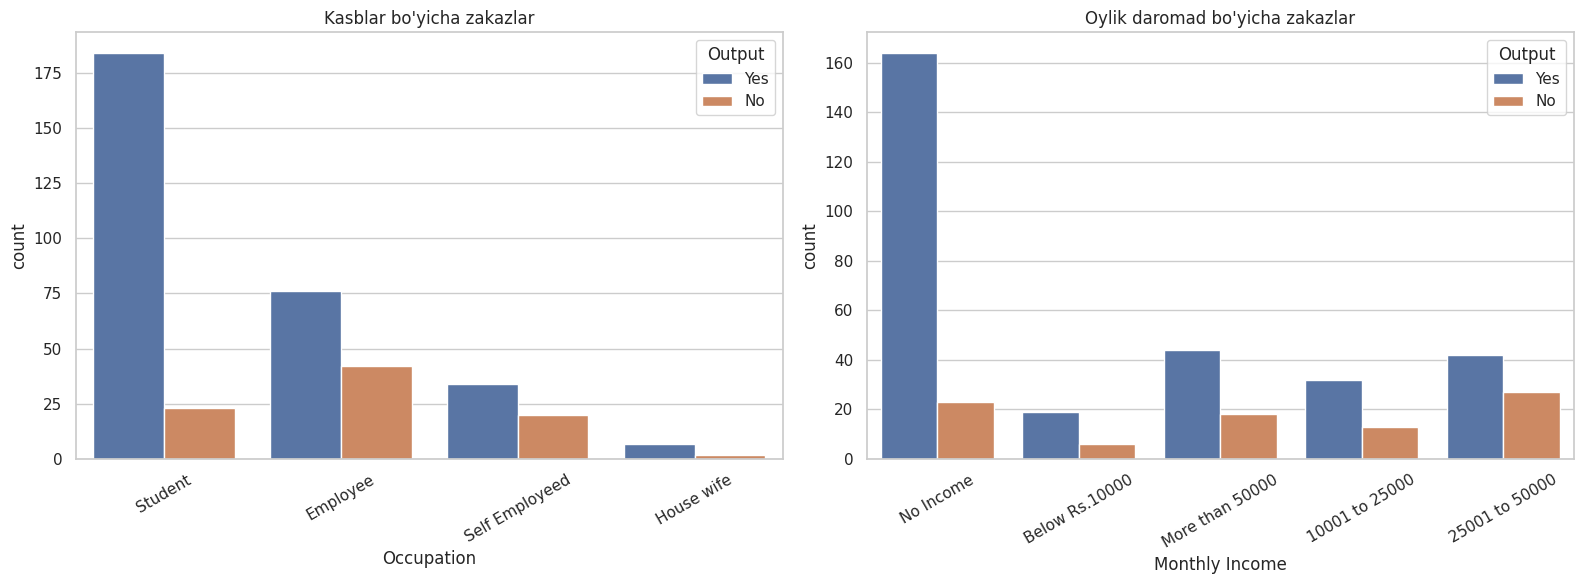

In [ ]:
# Daromad va Bandlik (Monthly Income, Occupation):
# Oylik daromadi yoki kasbi (masalan, studentlar va ishchilar) zakaz qilish qaroriga qanday ta'sir qiladi?
# 1. Daromad va Bandlik ustunlarini ajratib ko'rish
daromad_bandlik = df[['Monthly Income', 'Occupation']]

# 2. Kasb va daromad bo'yicha Output (zakaz) sonini kamayish tartibida ko'rish
print(df.groupby(['Occupation', 'Monthly Income'])['Output'].value_counts().sort_values(ascending=False))

# 3. Grafikka chiqarish
sns.set_theme(style='whitegrid')

# 1 ta qator, 2 ta ustunli grafik oynasi (1 qator bo'lgani uchun indexlar: axes[0], axes[1])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1-grafik: Occupation
sns.countplot(data=df, x='Occupation', hue='Output', ax=axes[0])
axes[0].set_title('Kasblar bo\'yicha zakazlar')
axes[0].tick_params(axis='x', rotation=30)  # Yozuvlar ustma-ust tushmasligi uchun buramiz

# 2-grafik: Monthly Income
sns.countplot(data=df, x='Monthly Income', hue='Output', ax=axes[1])
axes[1].set_title('Oylik daromad bo\'yicha zakazlar')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


Oylik daromadi yoki kasbi (masalan, studentlar va ishchilar) zakaz qilish qaroriga qanday ta'sir qiladi?

Analiz :

Kasbi boyicha: Studentlar eng kopi zakaz qilishgan va eng kami house wife, avarage :employee va self employeed.

Oylik boyicha: No income(oyliki yoqlar eng kop zakaz qilishgan ) va bu korsarkich aynan 157 zakaz bilan studentlarda uchragan yani ishlashmaydi ammo zakaz qila olishadi.
Keyingi orinda esa Employeelar 25001 to 50000 oraliqda daromad bilan 33 ta zakaz qilishgan va More than 50000 daromad bilan 24 ta zakaz.
Self employeed lar More than 50000 daromad bilan 18 ta zakaz.

Xulosa:

**Talabalar asosiy drayver**: Platformaning eng faol mijozlari — talabalar (Student). Ular rasmiy daromadga ega boʻlmasa-da (No Income), 157 ta doimiy zakaz bilan mutlaq yetakchilik qilmoqda. Bu talabalarning vaqtni tejash va qulaylik uchun onlayn ovqat yetkazib berish xizmatidan maksimal foydalanishini koʻrsatadi.

**Ishlaydigan segment barqarorligi**: Xodimlar (Employee) oʻrta va yuqori daromad guruhlarida (25,001 to 50,000 va More than 50,000) eng koʻp zakaz bergan ikkinchi asosiy qatlam hisoblanadi. Ularning daromadi oshgani sari onlayn zakaz berishga moyilligi ham yuqori saqlanib qoladi.

**Uy bekasi va Tadbirkorlar**: Oʻzini band qilganlar (Self Employeed) barqaror oʻrta ulushni tashkil etadi, uy bekalari (House wife) esa eng kam zakaz beradigan segmentdir (chunki ular odatda uyda ovqat tayyorlashadi).


Soni bo'yicha:
Family size  Output
1            Yes       17
             No         7
2            Yes       79
             No        22
3            Yes       93
             No        24
4            Yes       54
             No         9
5            Yes       40
             No        14
6            Yes       18
             No        11
Name: count, dtype: int64

Foiz hisobida:
Family size  Output
1            Yes       70.833333
             No        29.166667
2            Yes       78.217822
             No        21.782178
3            Yes       79.487179
             No        20.512821
4            Yes       85.714286
             No        14.285714
5            Yes       74.074074
             No        25.925926
6            Yes       62.068966
             No        37.931034
Name: proportion, dtype: float64


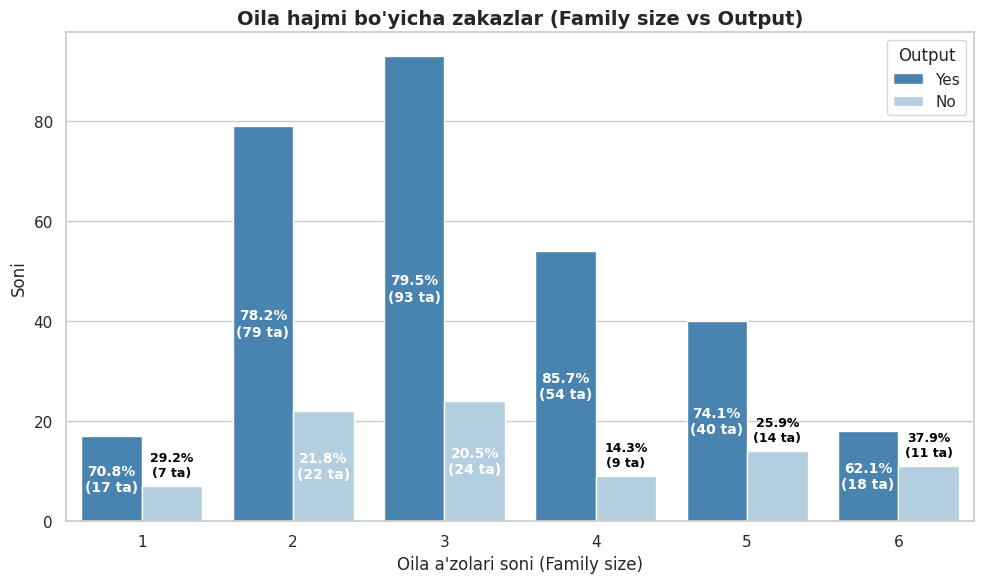

In [ ]:
# Oila hajmi (Family size): Yolg‘iz yashaydiganlar ko‘proq zakaz qiladimi yoki katta oilalar?

# 1. Sanab olish va foizni hisoblash
counts = df.groupby("Family size")["Output"].value_counts()
print("Soni bo'yicha:")
print(counts)

print("\nFoiz hisobida:")
print(df.groupby("Family size")["Output"].value_counts(normalize=True) * 100)

# 2. Grafik yaratish
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x="Family size", hue="Output", palette="Blues_r")
plt.title('Oila hajmi bo\'yicha zakazlar (Family size vs Output)', fontsize=14, fontweight='bold')
plt.xlabel('Oila a\'zolari soni (Family size)')
plt.ylabel('Soni')

# Har bir oila hajmi bo'yicha umumiy sonini olamiz
family_totals = df.groupby("Family size").size()
family_sizes = sorted(df['Family size'].unique())

# Ustunlar ustiga tegishli guruh foizini yozamiz
for p in ax.patches:
    height = p.get_height()
    if pd.isna(height) or height == 0:
        continue

    # Ustun qaysi x-kategoriyaga tegishli ekanini aniqlaymiz
    x_idx = int(round(p.get_x() + p.get_width() / 2.)) % len(family_sizes)
    fam_size = family_sizes[x_idx]
    fam_total = family_totals[fam_size]

    perc = (height / fam_total) * 100

    # Katta ustunlar ichiga, kichiklarining tepasiga yozamiz
    if height > 15:
        ax.annotate(f'{perc:.1f}%\n({int(height)} ta)',
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='center',
                    fontsize=10, color='white', fontweight='bold')
    else:
        ax.annotate(f'{perc:.1f}%\n({int(height)} ta)',
                    (p.get_x() + p.get_width() / 2., height + 1.5),
                    ha='center', va='bottom',
                    fontsize=9, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

Oila hajmi (Family size): Yolg‘iz yashaydiganlar ko‘proq zakaz qiladimi yoki katta oilalar?

Xulosa (Oila hajmi boʻyicha tahlil):

Eng faol hajmdagi oilalar (2-3 kishilik): Absolyut soni boʻyicha eng koʻp buyurtma 3 kishilik (93 ta buyurtma, 79.5%) va 2 kishilik (79 ta buyurtma, 78.2%) oilalarga toʻgʻri keladi. Bu xizmatning asosiy auditoriyasi kichik va oʻrta oilalar ekanini koʻrsatadi.

Moyilligi eng yuqori qatlam (4 kishilik): Nisbiy foiz hisobida 4 kishilik oilalarning zakaz qilish moyilligi eng yuqori — 85.7% (54 ta Yes va atigi 9 ta No).

Yolgʻiz yashaydiganlar hamda katta oilalar: Yolgʻizlar (1 kishilik) ham yetarlicha faol (70.8% Yes), lekin umumiy hajmda ularning ulushi kamroq. Oila a'zolari 6 kishidan oshganda esa zakaz qilmaslik koʻrsatkichi (No) sezilarli darajada oshadi (37.9%).

Feedback   Output
Negative   No        74.6
           Yes       25.4
Positive   Yes       89.3
           No        10.7
Name: proportion, dtype: float64


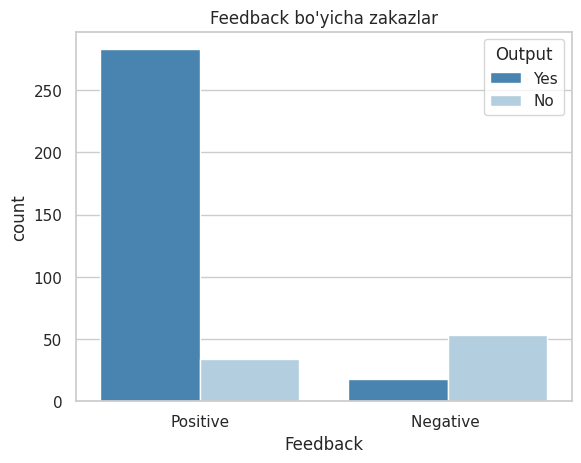

In [ ]:
# Feedback ta'siri (Feedback): Ijobiy (Positive) fikr bildirganlar doim zakaz qiladimi?
# Salbiy (Negative) fikr bildirganlar orasida ham zakaz qiladiganlar bormi?

# corr with groupby
corr_matrix_feedback = (df.groupby("Feedback")["Output"].value_counts(normalize=True) * 100).round(1)
print(corr_matrix_feedback)

sns.countplot(data=df, x="Feedback", hue="Output", palette="Blues_r")
plt.title('Feedback bo\'yicha zakazlar')
plt.show()



Xulosa (Feedback boʻyicha tahlil):

Ijobiy fikr (Positive) — Yuqori sodiqlik: Ijobiy fikr bildirgan mijozlarning mutloq koʻpchiligi — 89.3 foizi yana qayta buyurtma berishda davom etadi. Bu mijoz mamnuniyati va xizmat sifatining sodiqlikka toʻgʻridan-toʻgʻri ta'sirini koʻrsatadi.

Salbiy fikr (Negative) — Mijozlarni yoʻqotish: Salbiy fikr bildirganlarning 74.6 foizi keyinchalik zakaz berishdan voz kechgan (No).
Kutilmagan koʻrsatkich (Paradoks): Salbiy fikr qoldirgan boʻlsa-da, 25.4 foiz mijozlar hali ham zakaz berishda davom etmoqda. Bu xizmatning qulayligi yoki muqobil variantlar yoʻqligi sababli boʻlishi mumkin.

Customer Type  Output
Frequent       Yes       112
               No         34
New            Yes        17
               No          7
Regular        Yes       172
               No         46
Name: count, dtype: int64

Foiz hisobida:
Customer Type  Output
Frequent       Yes       76.712329
               No        23.287671
New            Yes       70.833333
               No        29.166667
Regular        Yes       78.899083
               No        21.100917
Name: proportion, dtype: float64


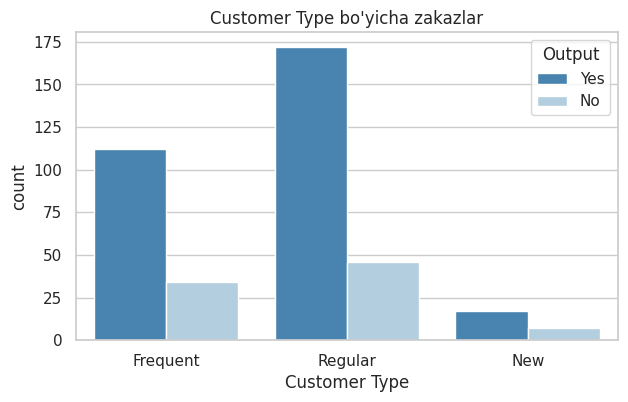

In [ ]:
# Customer Type bo'yicha zakazlar nisbati
print(df.groupby("Customer Type")["Output"].value_counts())
print("\nFoiz hisobida:")
print(df.groupby("Customer Type")["Output"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Customer Type", hue="Output", palette="Blues_r")
plt.title("Customer Type bo'yicha zakazlar")
plt.show()

Gender  Output
Female  Yes       75.903614
        No        24.096386
Male    Yes       78.828829
        No        21.171171
Name: proportion, dtype: float64


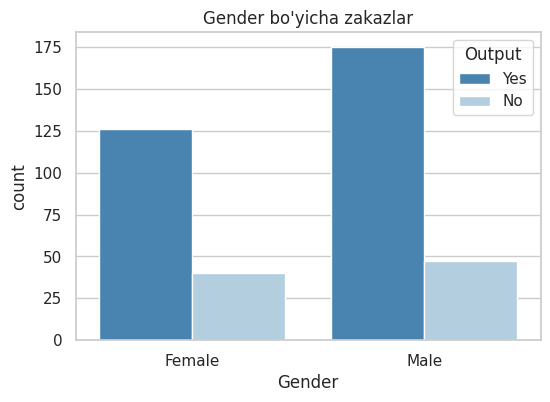

In [ ]:
# Jins bo'yicha zakazlar foizini ko'rish
print(df.groupby("Gender")["Output"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender", hue="Output", palette="Blues_r")
plt.title("Gender bo'yicha zakazlar")
plt.show()

Umumiy EDA hulosasi:
Output bir xil taqsimlanmagan bolib chiqdi yani malumotlarni 70 foizi Ordered bolgani uchun u modelni yes yani buyurtma berganga tortishga moiligi yuqori natijada esa : overfittingga uchrashi mumkin. bu muamoni hal qilamiz: keyngi modellashtrish bosqichda.

Age ustini eng kob corr oldi. Yani zakaz berish bermaslikka yosh juda katta tasir qilgan.Bu ustun ayni Feature bob.

shu orinda daromad va kim bolib ishlashi ham,hali ishlamaydigan studentlar eng kop zakaz qilgan ekan va ishlaydiganlar 2 chi darajadegi zakaz qiladigan qattlam.

Qoshimchasiga oilalar soni ham katta rol oynagan yani orta kichik hol oilalar kop zakaz qilishga moillik bolgan,katta oillarga qaraganda.

Feedback yaxshilar kop zakaz berishgan,negative feedbackkga qaraganda,bu yerda etbor berish kk bolgan masala yetqazib berish sifati qanchalik baland bolsa shuncha feedbacklar yaxshi boladi va zakaz berish ehtimoli yuqorilashadi.

Buyurtma berish turiga qarasak eng kop har doim zakaz berib yurganlar ekan,yani biror bir onlayn buyurtma bersa boladigan platformaga har doim zakaz berib yurganla yuqori boladi yangi kirgan mijozga qaraganda,Bu narsa ozi mantiqan ham tusharli shu sababi bu ustunni biz Featuresga bermasak ham boladi.

In [ ]:
# Cladue bergan feedback :



EDA'dagi kuchli va zaif tomonlar

Yaxshi qilingan:

Target balance (77.6% vs 22.4%) — imbalance borligini to'g'ri aniqlagansiz va bu overfitting xavfini oldindan ko'ra bilgansiz. Bu juda muhim, ko'pchilik junior buni umuman e'tiborsiz qoldiradi.
Har bir feature uchun target bilan bog'liqligini alohida ko'rib chiqish — to'g'ri yondashuv.

Xulosalaringizda ehtiyot bo'lish kerak bo'lgan joylar:

"Age eng ko'p corr oldi" — bu yerda siz aslida correlation coefficient hisoblamagansiz, shunchaki groupby orqali taqsimotni ko'rgansiz. Bu statistik jihatdan noto'g'ri xulosa. Kategorik target (Yes/No) bilan raqamli feature (Age) orasidagi bog'liqlikni ko'rish uchun sizga kerak:
Point-biserial correlation, yoki
Oddiygina df.groupby("Output")["Age"].describe() — ikkala guruhning mean/median/std sini solishtiring
Yoki target'ni 0/1 ga o'tkazib, .corr() chaqiring
Hozirgi holatda "Age eng katta ta'sir qiladi" deyish — hali isbotlanmagan taxmin, xulosa emas.
Kichik dataset muammosi: 388 qator — bu juda kichik dataset. 5-6 ta xulosa chiqarayotganingizda (masalan, "6 kishilik oilalar kamroq zakaz beradi — 18 ta Yes, 11 ta No"), bu atigi 29 ta odam degani. Bunday kichik sample'larga statistik xulosa chiqarish xavfli — bu shunchaki shovqin (noise) bo'lishi mumkin. Senior daraja: har bir guruhning n (sample size) qancha ekanini yozib borish, va n<30 bo'lgan guruhlarga ehtiyotkorlik bilan qarash.
Feedback ustuni — ehtiyot bo'ling, bu "leakage" bo'lishi mumkin. Mijoz "Positive/Negative" feedback berishi ko'pincha buyurtma bergandan KEYIN sodir bo'ladi. Agar sizning target'ingiz "keyingi safar zakaz qiladimi" bo'lsa, Feedback aslida kelajakni bilib turgan proxy bo'lib qolishi mumkin (masalan model realda ishlatib bo'lmaydigan "kelajakdagi ma'lumotdan" foydalanadi). Bu — data leakagening klassik ko'rinishi. Buni albatta domain nuqtai nazaridan tekshiring: Feedback qачон yig'ilgan — model production'da ishlaganda bu ustun mavjud bo'ladimi?

Demak, Feedback faqat zakaz berib boʻlgan odamda mavjud boʻladi. Agar sen buni modelga topshirsang, model faqat Feedback bor-yoʻqligiga qarab javob berishni oʻrganib oladi va real hayotda (yangi mijozlarda) mutlaqo ishlamay qoladi. Bu classic Data Leakage hisoblanadi.

-0.2480522590944822
        count       mean       std   min   25%   50%   75%   max
Output                                                          
No       87.0  26.000000  2.921452  19.0  24.0  26.0  28.0  33.0
Yes     301.0  24.232558  2.876179  18.0  22.0  24.0  25.0  32.0


<>:15: SyntaxWarning: invalid escape sequence '\y'
<>:15: SyntaxWarning: invalid escape sequence '\y'
/tmp/ipykernel_1219/3178381725.py:15: SyntaxWarning: invalid escape sequence '\y'
  axes[1].set_title('Yosh bo\yicha zakazlar tarqalishi')


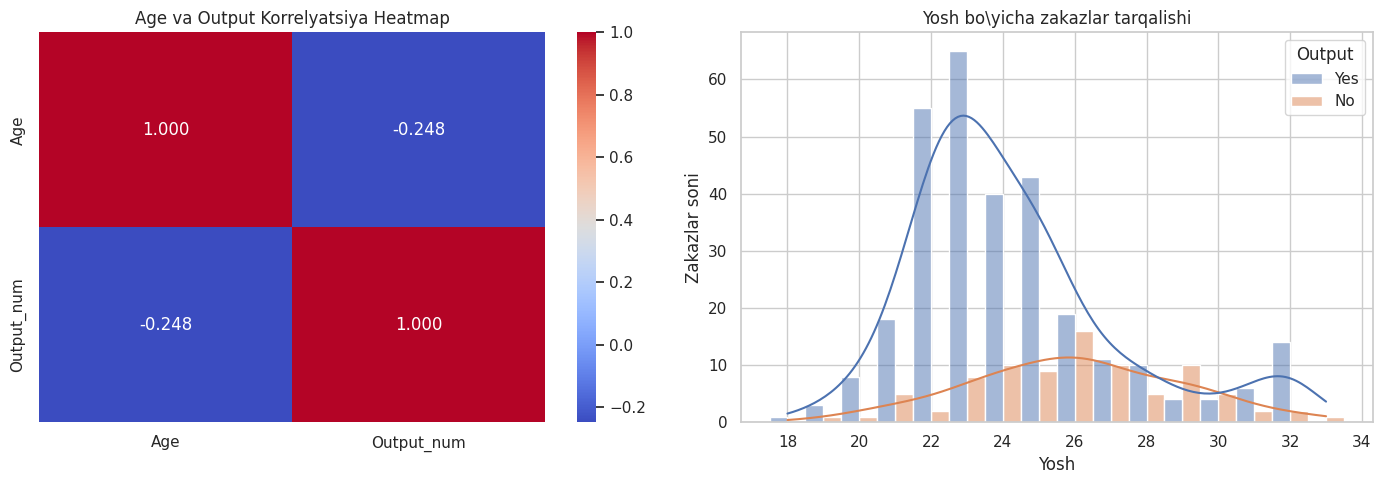

In [ ]:
df_copy = df.copy()
df_copy["Output_num"] = df_copy["Output"].map({"Yes":1, "No":0})
corr_val = df_copy["Age"].corr(df_copy["Output_num"])
print(corr_val)

print(df_copy.groupby("Output")["Age"].describe())

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_copy[['Age', 'Output_num']].corr(), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[0])
axes[0].set_title('Age va Output Korrelyatsiya Heatmap')
sns.histplot(data=df, x="Age", hue="Output", kde=True, discrete=True, multiple="dodge", ax=axes[1])
axes[1].set_xlabel('Yosh')
axes[1].set_ylabel('Zakazlar soni')
axes[1].set_title('Yosh bo\yicha zakazlar tarqalishi')

plt.tight_layout()
plt.show()

# Manosi: Yosh kattalashgani sari onlayn ovqat zakaz qilish ehtimoli malum darajada kamayadi. Yoshroq mijozlar zakaz berishga kopro moyil.

*"Age va Target oʻrtasida −0.248 manfiy korrelyatsiya mavjud. Buyurtma bergan mijozlarning oʻrtacha yoshi 24.2 yoshni, bermaganlarniki esa 26.0 yoshni tashkil etdi. Yosh kattalashgani sari zakaz berish moyilligi biroz pasayishi kuzatilsa-da, bu ustun yagona hal qiluvchi belgi emas. Shuning uchun Age ustuni qolgan demografik va ijtimoiy belgilar (Occupation, Monthly Income) bilan birgalikda qaralgandagina kuchli signal beradi."*

In [ ]:
# 1. Keraksiz/shovqin ustunlarni va Data Leakage beruvchi ustunlarni tashlaymiz
df_clean = df.drop(columns=["Unnamed: 13", "latitude", "longitude", "Pin code", "Feedback", "Customer Type"], errors='ignore').copy()

# 2. Dublikatlarni tekshirish va olib tashlash
print(f"O'chirishdan oldingi qatorlar soni: {len(df_clean)}")
print(f"Topilgan dublikatlar soni: {df_clean.duplicated().sum()}")

# Dublikat qatorlarni o'chiramiz (birinchi nusxasini saqlab qoladi)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"O'chirilgandan keyingi toza qatorlar soni: {len(df_clean)}")
print("Target tarqalishi (dublikatsiz):")
print(df_clean['Output'].value_counts())

O'chirishdan oldingi qatorlar soni: 388
Topilgan dublikatlar soni: 152
O'chirilgandan keyingi toza qatorlar soni: 236
Target tarqalishi (dublikatsiz):
Output
Yes    175
No      61
Name: count, dtype: int64


# Train va Testga bolish


In [ ]:
from sklearn.model_selection import train_test_split
# train va testga bolish uchun kutubxonasi

In [ ]:
train_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean["Output"],
)
print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

print("hammasi:")
print(df_clean["Output"].value_counts(normalize=True))

print("Train:")
print(train_df["Output"].value_counts(normalize=True))

print("Test:")
print(test_df["Output"].value_counts(normalize=True))


Train dataset shape: (188, 8)
Test dataset shape: (48, 8)
hammasi:
Output
Yes    0.741525
No     0.258475
Name: proportion, dtype: float64
Train:
Output
Yes    0.739362
No     0.260638
Name: proportion, dtype: float64
Test:
Output
Yes    0.75
No     0.25
Name: proportion, dtype: float64


#Feature Engineering

Encoding qilishdan oldin modelga qaysi belgilarni beramiz va ularni qanday tayyorlaymiz:

Mantiq shunday: Feature Engineering bosqichida siz "qaysi ustunlarni qanday shaklda modelga beraman" degan qarorni qabul qilasiz (masalan Age'ni guruhlarga bo'lish, yangi ustun yaratish). Bu qarorlar qabul qilingandan keyin, hosil bo'lgan yakuniy ustunlar to'plamini raqamli formatga (Encoding) o'tkazasiz. Aksincha qilsangiz — avval encode qilib, keyin feature engineering qilsangiz — encode qilingan ustunlarni yana qayta ishlashga to'g'ri keladi, bu ortiqcha ish.

In [ ]:

# 1. Age_Group yaratamiz
train_df['Age_Group'] = pd.cut(
    train_df['Age'],
    bins=[-float('inf'), 22, 26, float('inf')],
    labels=['junior', 'adults', 'senior']
)

# 2. Is_Student_No_Income yaratamiz (1 yoki 0)
train_df['Is_Student_No_Income'] = (
    (train_df['Occupation'] == 'Student') &
    (train_df['Monthly Income'] == 'No Income')
).astype(int)

# 3. Is_Large_Family yaratamiz (1 yoki 0)
train_df['Is_Large_Family'] = (train_df['Family size'] >= 6).astype(int)

# Natijani tekshirish
train_df[['Age', 'Age_Group', 'Occupation', 'Monthly Income', 'Is_Student_No_Income', 'Family size', 'Is_Large_Family']].head()

,Age,Age_Group,Occupation,Monthly Income,Is_Student_No_Income,Family size,Is_Large_Family
103,22,junior,Student,No Income,1,3,0
10,22,junior,Student,No Income,1,5,0
27,23,adults,Employee,10001 to 25000,0,3,0
149,23,adults,Student,No Income,1,2,0
212,24,adults,Employee,10001 to 25000,0,2,0


In [ ]:
def add_features(df):
    df = df.copy()
    df['Age_Group'] = pd.cut(df['Age'], bins=[-float('inf'), 22, 26, float('inf')],
                               labels=['junior', 'adults', 'senior'])
    df['Is_Student_No_Income'] = ((df['Occupation'] == 'Student') &
                                    (df['Monthly Income'] == 'No Income')).astype(int)
    df['Is_Large_Family'] = (df['Family size'] >= 6).astype(int)
    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

In [ ]:
train_df['Age_Group'].value_counts()

,count
Age_Group,
adults,99
senior,47
junior,42


#Encoding

hozir bunday ustunlar bor:

Nominal (tartibsiz) categorical: Gender, Marital Status, Occupation, Age_Group

Ordinal (tartibli) categorical: Monthly Income (No Income < Below 10000 < ... < More than 50000), Educational Qualifications (School < Graduate < Post Graduate < Ph.D — agar shunday tartib to'g'ri deb hisoblasangiz)

Binary (allaqachon 0/1): Is_Student_No_Income, Is_Large_Family
Target: Output (Yes/No → 1/0 qilish kerak)

In [ ]:
# nominallarni one hot encoding qilamiz.ordinal esa label encoding qilsak menimcha boladi,binary va targetni map orqali qilsak boladi

"Label Encoding" atamasi bilan chalkashlik bor

Sklearn'da LabelEncoder degan alohida klass bor, va u aslida tartibni hurmat qilmaydi — u kategoriyalarni shunchaki alfavit tartibida 0, 1, 2, 3... qilib raqamlaydi. Masalan Monthly Income uchun:


```
from sklearn.preprocessing import LabelEncoder
# Alfavit tartibida: "10001 to 25000", "25001 to 50000", "Below Rs.10000", "More than 50000", "No Income"
# → 0, 1, 2, 3, 4
```
Ko'rdingizmi — bu mantiqiy tartibga to'g'ri kelmaydi! "No Income" (eng past daromad) 4 raqamini oladi, "10001 to 25000" esa 0 raqamini oladi. Model buni "No Income eng yuqori daraja" deb tushunib qoladi — bu xato signal.



To'g'ri yechim: Ordinal Encoding, lekin tartibni qo'lda ko'rsatib

Ordinal ustunlar uchun sizga kerak bo'lgan narsa — OrdinalEncoder (tartibni o'zingiz belgilab):

In [ ]:
print(df_clean['Educational Qualifications'].unique())

['Post Graduate' 'Graduate' 'Ph.D' 'Uneducated' 'School']


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Ustunlar turini matnga (string) o'tkazamiz
train_df["Monthly Income"] = train_df["Monthly Income"].astype(str)
train_df["Educational Qualifications"] = train_df[
    "Educational Qualifications"
].astype(str)

test_df["Monthly Income"] = test_df["Monthly Income"].astype(str)
test_df["Educational Qualifications"] = test_df[
    "Educational Qualifications"
].astype(str)

# Shundan so'ng encoder'ni ishlatasiz
encoder = OrdinalEncoder(categories=[income_order, education_order])

train_df[["Monthly Income", "Educational Qualifications"]] = (
    encoder.fit_transform(
        train_df[["Monthly Income", "Educational Qualifications"]]
    )
)
test_df[["Monthly Income", "Educational Qualifications"]] = encoder.transform(
    test_df[["Monthly Income", "Educational Qualifications"]]
)

train_df

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Age_Group,Is_Student_No_Income,Is_Large_Family
103,22,Female,Single,Student,0.0,2.0,3,Yes,junior,1,0
10,22,Female,Single,Student,0.0,3.0,5,Yes,junior,1,0
27,23,Female,Single,Employee,2.0,2.0,3,Yes,adults,0,0
149,23,Female,Single,Student,0.0,2.0,2,No,adults,1,0
212,24,Female,Married,Employee,2.0,3.0,2,Yes,adults,0,0
...,...,...,...,...,...,...,...,...,...,...,...
25,25,Male,Single,Student,0.0,3.0,3,Yes,adults,1,0
225,24,Female,Single,Student,0.0,3.0,5,No,adults,1,0
58,22,Female,Single,Student,0.0,3.0,3,Yes,junior,1,0
104,25,Male,Married,Employee,3.0,2.0,2,Yes,adults,0,0


In [ ]:
from sklearn.preprocessing import OneHotEncoder
# 1. Kodlamoqchi bo'lgan ustunlarimiz ro'yxati
cat_cols = ["Gender", "Marital Status", "Occupation", "Age_Group"]

# 2. OneHotEncoder obyektini yaratamiz
one_encoder = OneHotEncoder(sparse_output=False, drop="first")

# 3. Fit va transform qilamiz hamda yangi ustun nomlari bilan DataFrame yaratamiz
train_encoded = pd.DataFrame(
    one_encoder.fit_transform(train_df[cat_cols]),
    columns=one_encoder.get_feature_names_out(cat_cols),
    index=train_df.index,
)

test_encoded = pd.DataFrame(
    one_encoder.transform(test_df[cat_cols]),
    columns=one_encoder.get_feature_names_out(cat_cols),
    index=test_df.index,
)

# 4. Eski matnli ustunlarni o'chirib, yangi kodlangan ustunlarni qo'shamiz
train_df = pd.concat(
    [train_df.drop(columns=cat_cols), train_encoded], axis=1
)
test_df = pd.concat([test_df.drop(columns=cat_cols), test_encoded], axis=1)

# Natijani tekshirish
print(train_df.head())

     Age  Monthly Income  Educational Qualifications  Family size Output  \
103   22             0.0                         2.0            3    Yes   
10    22             0.0                         3.0            5    Yes   
27    23             2.0                         2.0            3    Yes   
149   23             0.0                         2.0            2     No   
212   24             2.0                         3.0            2    Yes   

     Is_Student_No_Income  Is_Large_Family  Gender_Male  \
103                     1                0          0.0   
10                      1                0          0.0   
27                      0                0          0.0   
149                     1                0          0.0   
212                     0                0          0.0   

     Marital Status_Prefer not to say  Marital Status_Single  \
103                               0.0                    1.0   
10                                0.0                    1.0

In [ ]:
print(train_df['Output'].unique())

['Yes' 'No']


In [ ]:
# Is_Student_No_Income, Is_Large_Family Target: Output
train_df["Output"] =train_df["Output"].map({"Yes": 1, "No": 0})
test_df["Output"] =test_df["Output"].map({"Yes": 1, "No": 0})
train_df.head()

,Age,Monthly Income,Educational Qualifications,Family size,Output,Is_Student_No_Income,Is_Large_Family,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_House wife,Occupation_Self Employeed,Occupation_Student,Age_Group_junior,Age_Group_senior
103,22,0.0,2.0,3,1,1,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
10,22,0.0,3.0,5,1,1,0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
27,23,2.0,2.0,3,1,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
149,23,0.0,2.0,2,0,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
212,24,2.0,3.0,2,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
